In [1]:
import clickhouse_connect
import matplotlib.pyplot as plt

Подключение к ClickHouse-кластеру (ch12) и проверка работоспособности

In [2]:
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username='default',
    password='homework'
)

result = client.query('SELECT version()')
print(f'ClickHouse version: {result.first_row[0]}')

ClickHouse version: 25.8.33.6


# 0. Генерация данных для заполнения таблиц

In [3]:
print("Удаление предыдущей БД со сгенерированными данными")
client.command("DROP DATABASE IF EXISTS homework_data")

print("Создание базы данных homework_data")
client.command("CREATE DATABASE homework_data")

print("Создание локальной таблицы")
client.command("""
CREATE TABLE homework_data.push_events_source
(
    event_dt   DateTime,
    event_id   UInt64,
    user_id    UInt64,
    message_id UInt64,
    platform   LowCardinality(String),
    status     LowCardinality(String),
    latency_ms UInt32
)
ENGINE = MergeTree
PARTITION BY toYYYYMMDD(event_dt)
ORDER BY (event_dt, user_id, event_id)
SETTINGS index_granularity = 8192
""")

print("Генерация 2.000.000 событий")
client.command("""
INSERT INTO homework_data.push_events_source
SELECT
    now() - (rand64(1) % (30 * 86400))                   AS event_dt,
    number                                               AS event_id,
    rand64(2) % 10000                                    AS user_id,
    rand64(3) % 1000000                                  AS message_id,
    ['ANDROID', 'IOS', 'WEB', 'DESKTOP']
        [toInt8(rand64(4) % 4) + 1]                      AS platform,
    ['delivered', 'failed', 'opened']
        [toInt8(rand64(5) % 3) + 1]                      AS status,
    toUInt32(1 + (rand64(6) % 5000))                     AS latency_ms
FROM numbers(2000000)
""")

# В задании 4 сказано, что в сгенерированных данных есть дубликаты (всё одинаковое, кроме event_dt)
print("Добавление 5% дубликатов")
client.command("""
INSERT INTO homework_data.push_events_source
SELECT
    event_dt + if(rand64(1) % 2 = 0,  3600, -3600)      AS event_dt,
    event_id,
    user_id,
    message_id,
    platform,
    status,
    latency_ms
FROM homework_data.push_events_source
WHERE rand64(7) % 100 < 5
""")

Удаление предыдущей БД со сгенерированными данными
Создание базы данных homework_data
Создание локальной таблицы
Генерация 2.000.000 событий
Добавление 5% дубликатов


In [4]:
res = client.query("SELECT count() FROM homework_data.push_events_source")
print(f"Всего строк в источнике: {res.first_row[0]}")

res = client.query("""
SELECT
    hostName() AS host,
    sum(rows)  AS rows
FROM clusterAllReplicas('homework_cluster', system.parts)
WHERE active
  AND database = 'homework_data'
  AND table = 'push_events_source'
GROUP BY host
ORDER BY host
""")
print("Строк в локальных таблицах на каждой реплике:")
for row in res.result_rows:
    print(row)

Всего строк в источнике: 2100172
Строк в локальных таблицах на каждой реплике:
('ch11', 2100172)


То есть успешно сгенерировали данные, которые локально лежат только на реплике 1 шарда 1

# 1. Создание Raw-слоя

In [5]:
db_name = "student_petrov"
cluster_name = "homework_cluster"
table_raw_local = "push_events_raw_local"
table_raw = "push_events_raw"

Создаём базу данных на кластере.
Под кластером подразумеваются логически объединённые узлы (ноды, сервера) в существующей архитектуре.

In [6]:
print(f"Создание/пересоздание базы данных {db_name}")
client.command(f"DROP DATABASE IF EXISTS {db_name} ON CLUSTER {cluster_name}")
client.command(f"CREATE DATABASE {db_name} ON CLUSTER {cluster_name}")

Создание/пересоздание базы данных student_petrov


['ch22',
 '9000',
 '0',
 '',
 '3',
 '0\nch12',
 '9000',
 '0',
 '',
 '2',
 '0\nch11',
 '9000',
 '0',
 '',
 '1',
 '0\nch21',
 '9000',
 '0',
 '',
 '0',
 '0']

Создаём локальную таблицу на всех узлах кластера. Требования по заданию:
1. Партиционирование по дню.
Это означает, что данные будут разбиваться на разные парты по значению колонки event_dt, т.е. по дате создания события.
2. TTL 30 дней от event_dt.
TTL (Time To Live) обозначает сколько времени будут храниться данные на узлах. Т.к. в любом парте события имеют один event_dt, то toDate() используется для того, чтобы сдалялся сразу весь парт целиком, а не проверялись все значения event_dt по отдельности.
3. Ordering Key для быстрого поиска по пользователю.
Так как нам важнее всего искать данные по пользователю, то сортироваться данные будут по user_id, затем event_dt, затем event_id.
4. Выбрать правильный sharding key для Distributed (равномерное распределение).
Для равномерного распределения достаточно указать рандомный ключ шардирования.

ReplicatedMergeTree - копирует данные между всеми репликами и гарантирует, что на всех репликах шарда будут одинаковые данные.

"Что будет, если вставлять данные в локальную таблицу, а не в Distributed?" - в таком случае вбсолютно все данные попадут только на шард этого узла и sharding key для распределения данных будет игнорироваться.

In [7]:
print("Создание локальной таблицы push_events_raw_local")
client.command(f"""
CREATE TABLE IF NOT EXISTS {db_name}.{table_raw_local} ON CLUSTER {cluster_name}
(
    event_dt   DateTime,
    event_id   UInt64,
    user_id    UInt64,
    message_id UInt64,
    platform   LowCardinality(String),
    status     LowCardinality(String),
    latency_ms UInt32
)
ENGINE = ReplicatedMergeTree(
    '/clickhouse/tables/{{shard}}/{db_name}/{table_raw_local}',
    '{{replica}}'
)
PARTITION BY toYYYYMMDD(event_dt)
ORDER BY (user_id, event_dt, event_id)
TTL toDate(event_dt) + INTERVAL 30 DAY
SETTINGS index_granularity = 8192
""")

Создание локальной таблицы push_events_raw_local


['ch22',
 '9000',
 '0',
 '',
 '3',
 '0\nch21',
 '9000',
 '0',
 '',
 '2',
 '0\nch12',
 '9000',
 '0',
 '',
 '1',
 '0\nch11',
 '9000',
 '0',
 '',
 '0',
 '0']

Локальная (local) таблица - буквально физическая таблица, которая хранится на некотором узле. Как это работает в нашем случае:
1. Сначал создаётся кластер из 4 узлов (физических серверов) и 2 шардов. Т.е. 2 сервера хранят информацию шарда 1, а другие 2 сервера хранят информацию с шарда 2.
2. Создаётся локальная таблица на кластере. После этого на каждом узле появляется эта таблица со всеми её столбцами (пока без данных).
3. Если попробовать записать данные в одну из таких таблиц, то они будут только на этом сервере этого узла. То есть распределение по шардам через ключ шардирования будет игнорироваться, т.к. он настраивается только на распределённых таблицах. Однако если в качестве движка локальной таблицы использовать ReplicatedMergeTree, то данные всё равно будут дублироваться между репликами.

Распределённая (distributed) таблица - логическая таблица, которая работает с данными со всех локальных таблиц. При добавлении данных через распределённую таблицу все данные распределяются по шардам, согласно ключу шардирования, и затем все данные дублируются по всем шардам. Т.е. все данные разделяются на 2 части (2 шарда), между которыми данные не повторяются. При чтении данных через распределённую таблицу запрос на чтение отправляется на все шарды и какая-то из менее загруженных реплик обрабатывает этот запрос.

In [8]:
print(f"Создание распределённной таблицы push_events_raw")
client.command(f"""
CREATE TABLE IF NOT EXISTS {db_name}.{table_raw} ON CLUSTER {cluster_name}
AS {db_name}.{table_raw_local}
ENGINE = Distributed(
    '{cluster_name}',
    '{db_name}',
    '{table_raw_local}',
    rand()
)
""")

Создание распределённной таблицы push_events_raw


['ch21',
 '9000',
 '0',
 '',
 '3',
 '0\nch11',
 '9000',
 '0',
 '',
 '2',
 '0\nch12',
 '9000',
 '0',
 '',
 '1',
 '0\nch22',
 '9000',
 '0',
 '',
 '0',
 '0']

In [9]:
print(f"Копирование данных из homework_data.push_events_source в {db_name}.{table_raw}")
client.command(f"""
INSERT INTO {db_name}.{table_raw}
SELECT * FROM homework_data.push_events_source
""")

Копирование данных из homework_data.push_events_source в student_petrov.push_events_raw


Всё создали, теперь проверим что лежит в локальных таблицах. Будем создавать запросы к распределённой таблице.

Всего строк: 2071667
Распределение данных по шардам:
host  parts   total_rows size_on_disk
ch11     32 1.04 million    19.58 MiB
ch12     32 1.04 million    19.58 MiB
ch21     31 1.04 million    19.55 MiB
ch22     31 1.04 million    19.55 MiB


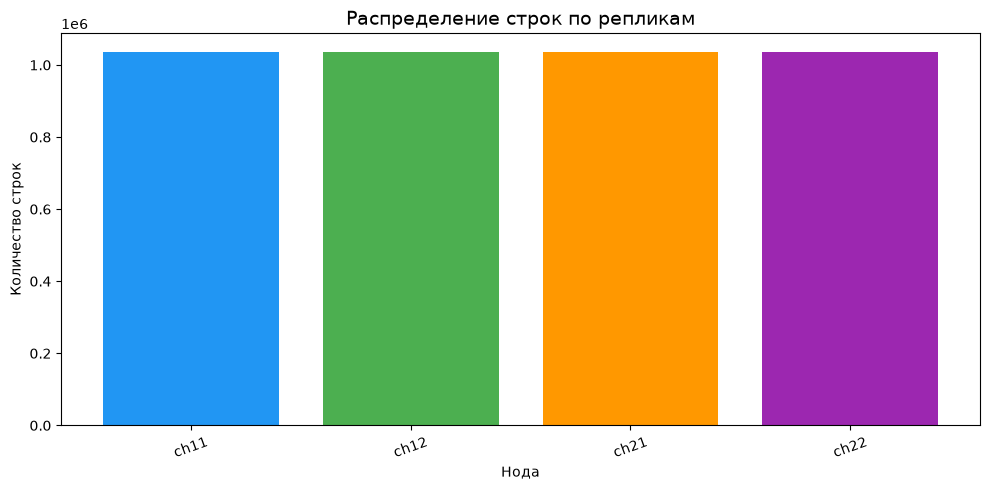

In [10]:
res = client.query(f"SELECT count() FROM {db_name}.{table_raw}")
print(f"Всего строк: {res.first_row[0]}")

df = client.query_df(f"""
SELECT
    hostName()                              AS host,
    count()                                 AS parts,
    formatReadableQuantity(sum(rows))       AS total_rows,
    formatReadableSize(sum(bytes_on_disk))  AS size_on_disk
FROM clusterAllReplicas('{cluster_name}', system.parts)
WHERE active
    AND database = '{db_name}'
    AND table = '{table_raw_local}'
GROUP BY host
ORDER BY host
""")
print("Распределение данных по шардам:")
print(df.to_string(index=False))

df_vis = client.query_df(f"""
SELECT
    hostName()  AS host,
    sum(rows)   AS total_rows
FROM clusterAllReplicas('{cluster_name}', system.parts)
WHERE active
    AND database = '{db_name}'
    AND table = '{table_raw_local}'
GROUP BY host
ORDER BY host
""")

plt.figure(figsize=(10, 5))
plt.bar(df_vis['host'], df_vis['total_rows'], color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
plt.title('Распределение строк по репликам', fontsize=14)
plt.xlabel('Нода')
plt.ylabel('Количество строк')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Как видим получили равномерное распределение данных, но заметим страшную вещь - данных в таблице со сгенерированными значениями содержится 2100172 строк, а через распределённую таблицу нашлось только 2071667 строк. То есть не хватает 2100172 - 2071667 = 28505 строк. Проверим распределение строк в исходной таблице по датам:

In [11]:
df = client.query_df("""
SELECT toDate(event_dt) AS d, count() AS cnt
FROM homework_data.push_events_source
GROUP BY d
ORDER BY d
""")
print(df)

            d    cnt
0  2026-09-07  28505
1  2026-09-08  70337
2  2026-09-09  69808
3  2026-09-10  70335
4  2026-09-11  69640
5  2026-09-12  69914
6  2026-09-13  70022
7  2026-09-14  70101
8  2026-09-15  69891
9  2026-09-16  70132
10 2026-09-17  70270
11 2026-09-18  69853
12 2026-09-19  70102
13 2026-09-20  70196
14 2026-09-21  70295
15 2026-09-22  70385
16 2026-09-23  70106
17 2026-09-24  70288
18 2026-09-25  69638
19 2026-09-26  69940
20 2026-09-27  69802
21 2026-09-28  70247
22 2026-09-29  69988
23 2026-09-30  69430
24 2026-10-01  70150
25 2026-10-02  69957
26 2026-10-03  69877
27 2026-10-04  69996
28 2026-10-05  69616
29 2026-10-06  69494
30 2026-10-07  41857


Посмотрим на первую строчку и видим, что значения совпадают. Значит в исходной таблице содержится дата с уже просроченными событиями, которые сразу же удаляются из нашей таблицы raw-слоя.

In [163]:
# проверка, что все имеют is_readonly=0 и доп. информация
df = client.query_df(f"""
SELECT
    hostName()     AS host,
    database,
    table,
    is_readonly,
    absolute_delay,
    queue_size,
    log_pointer,
    total_replicas,
    active_replicas
FROM clusterAllReplicas('{cluster_name}', system.replicas)
WHERE database = '{db_name}'
ORDER BY host, table
""")
print(df.to_string(index=False))

host       database                 table  is_readonly  absolute_delay  queue_size  log_pointer  total_replicas  active_replicas
ch11 student_petrov push_events_raw_local            0               0           0          878               2                2
ch12 student_petrov push_events_raw_local            0               0           0          878               2                2
ch21 student_petrov push_events_raw_local            0               0           0          876               2                2
ch22 student_petrov push_events_raw_local            0               0           0          876               2                2


# 2. Агрегаты (AggregatingMergeTree + MV)

AggregatingMergeTree - нужен для предобработки данных через Materialized View (MV). ClickHouse заменяет все строки с одинаковым первичным ключом одной строкой (в пределах одной части данных), которая хранит комбинацию состояний агрегатных функций.

Мы создаём MV между двумя локальными таблицами - push_events_raw_local и push_events_agg_local. То есть если на push_events_raw_local придут какие-то данные, то они сначала пройдут предобработку, указанную в MV, а потом сохранятся в push_events_agg_local.

"Что произойдёт, если MV создать после вставки данных в raw?" - с уже существующими данными ничего не произойдёт. MV реагирует только на новые вставки в локальную таблицу.

"Что вернёт avgMerge без GROUP BY ? Будет ли это корректным средним?" - без GROUP BY avgMerge вернёт среднее значение по всей таблице, а не только по необходимому параметру. В результатае все данные схлопнутся в одну строку.

In [37]:
table_agg_local = "push_events_agg_local"
table_agg = "push_events_agg"
table_agg_mv = "push_events_agg_mv"

print(f"Создание локальной таблицы {db_name}.{table_agg_local}")
client.command(f"""
CREATE TABLE IF NOT EXISTS {db_name}.{table_agg_local} ON CLUSTER {cluster_name}
(
    event_date Date,
    platform   LowCardinality(String),
    count_state AggregateFunction(count),
    uniq_users_state AggregateFunction(uniq, UInt64),
    avg_latency_state AggregateFunction(avg, UInt32)
)
ENGINE = AggregatingMergeTree()
PARTITION BY toYYYYMM(event_date)
ORDER BY (event_date, platform)
""")

print(f"Создание распределённой таблицы {db_name}.{table_agg}")
client.command(f"""
CREATE TABLE IF NOT EXISTS {db_name}.{table_agg} ON CLUSTER {cluster_name}
AS {db_name}.{table_agg_local}
ENGINE = Distributed(
    '{cluster_name}',
    '{db_name}',
    '{table_agg_local}',
    rand()
)
""")

print(f"Создание Materialized View {db_name}.{table_agg_mv}")
client.command(f"""
CREATE MATERIALIZED VIEW IF NOT EXISTS {db_name}.{table_agg_mv} ON CLUSTER {cluster_name}
TO {db_name}.{table_agg_local}
AS SELECT
    toDate(event_dt) AS event_date,
    platform,
    countState() AS count_state,
    uniqState(user_id) AS uniq_users_state,
    avgState(latency_ms) AS avg_latency_state
FROM {db_name}.{table_raw_local}
GROUP BY event_date, platform
""")

# Т.к. mv никак не реагирует на данные, которые уже лежат в push_events_raw_local, то сначала полностью очистим эту таблицу,
# чтобы дважды не добавлять одни и те же данные в push_events_raw
client.command(f"TRUNCATE TABLE {db_name}.{table_raw_local} ON CLUSTER {cluster_name}")
client.command(f"TRUNCATE TABLE {db_name}.{table_agg_local} ON CLUSTER {cluster_name}")

# для корректной проверки, что OPTIMIZE работает сделаем 2 INSERT: где latency_ms > 2500 и latency_ms <= 2500
# тогда у нас для каждой даты будет по 2 парта, которые смогут смерджиться между собой
print(f"Вставляем данные в {db_name}.{table_raw} с latency_ms > 2500")
client.command(f"""
INSERT INTO {db_name}.{table_raw}
SELECT
    event_dt,
    event_id,
    user_id,
    message_id,
    platform,
    status,
    latency_ms
FROM homework_data.push_events_source
WHERE latency_ms > 2500
""")

print(f"Вставляем данные в {db_name}.{table_raw} с latency_ms <= 2500")
client.command(f"""
INSERT INTO {db_name}.{table_raw}
SELECT
    event_dt,
    event_id,
    user_id,
    message_id,
    platform,
    status,
    latency_ms
FROM homework_data.push_events_source
WHERE latency_ms <= 2500
""")

Создание локальной таблицы student_petrov.push_events_agg_local
Создание распределённой таблицы student_petrov.push_events_agg
Создание Materialized View student_petrov.push_events_agg_mv
Вставляем данные из student_petrov.push_events_raw с latency_ms > 2500
Вставляем данные из student_petrov.push_events_raw с latency_ms <= 2500


Теперь проведём проверки, что данные корректно попадают в push_events_agg и правильно обрабатываются.

До OPTIMIZE:

In [39]:
before = client.query(f"SELECT count() FROM {db_name}.{table_agg}")
print(f"\nСтрок в {table_agg} до OPTIMIZE: {before.first_row[0]}")

print(f"Значения агрегированных функций из таблицы {table_agg} до OPTIMIZE:")
df_agg = client.query_df(f"""
SELECT
    event_date,
    platform,
    countMerge(count_state)     AS total_events,
    uniqMerge(uniq_users_state) AS unique_users,
    avgMerge(avg_latency_state) AS avg_latency
FROM {db_name}.{table_agg}
GROUP BY event_date, platform
ORDER BY event_date, platform
LIMIT 8
""")
print(df_agg.to_string(index=False))

print(f"\nПосчитанные значения агрегированных функций из таблицы {table_raw} до OPTIMIZE:")
df_raw = client.query_df(f"""
SELECT
    toDate(event_dt) AS event_date,
    platform,
    count()          AS total_events,
    uniq(user_id)    AS unique_users,
    avg(latency_ms)  AS avg_latency
FROM {db_name}.{table_raw}
GROUP BY event_date, platform
ORDER BY event_date, platform
LIMIT 8
""")
print(df_raw.to_string(index=False))


Строк в push_events_agg до OPTIMIZE: 232
Значения агрегированных функций из таблицы push_events_agg до OPTIMIZE:
event_date platform  total_events  unique_users  avg_latency
2026-09-07  ANDROID          7204          4956  2492.120350
2026-09-07  DESKTOP          7131          4967  2494.720516
2026-09-07      IOS          7092          4928  2549.489143
2026-09-07      WEB          7078          4903  2504.653574
2026-09-08  ANDROID         17477          8105  2510.511072
2026-09-08  DESKTOP         17631          8131  2497.555385
2026-09-08      IOS         17423          8080  2486.044654
2026-09-08      WEB         17806          8170  2505.684208

Посчитанные значения агрегированных функций из таблицы push_events_raw до OPTIMIZE:
event_date platform  total_events  unique_users  avg_latency
2026-09-07  ANDROID          7204          4956  2492.120350
2026-09-07  DESKTOP          7131          4967  2494.720516
2026-09-07      IOS          7092          4928  2549.489143
2026-09-

После OPTIMIZE:

In [42]:
print("Запуск OPTIMIZE")
client.command(f"OPTIMIZE TABLE {db_name}.{table_agg_local} ON CLUSTER {cluster_name} FINAL")

after = client.query(f"SELECT count() FROM {db_name}.{table_agg}")
print(f"Строк в {table_agg} ПОСЛЕ OPTIMIZE: {after.first_row[0]}")

print(f"Значения агрегированных функций из таблицы {table_agg} после OPTIMIZE:")
df_agg = client.query_df(f"""
SELECT
    event_date,
    platform,
    countMerge(count_state)     AS total_events,
    uniqMerge(uniq_users_state) AS unique_users,
    avgMerge(avg_latency_state) AS avg_latency
FROM {db_name}.{table_agg}
GROUP BY event_date, platform
ORDER BY event_date, platform
LIMIT 8
""")
print(df_agg.to_string(index=False))

print(f"\nПосчитанные значения агрегированных функций из таблицы {table_raw} после OPTIMIZE:")
df_raw = client.query_df(f"""
SELECT
    toDate(event_dt) AS event_date,
    platform,
    count()          AS total_events,
    uniq(user_id)    AS unique_users,
    avg(latency_ms)  AS avg_latency
FROM {db_name}.{table_raw}
GROUP BY event_date, platform
ORDER BY event_date, platform
LIMIT 8
""")
print(df_raw.to_string(index=False))

Запуск OPTIMIZE
Строк в push_events_agg ПОСЛЕ OPTIMIZE: 124
Значения агрегированных функций из таблицы push_events_agg после OPTIMIZE:
event_date platform  total_events  unique_users  avg_latency
2026-09-07  ANDROID          7204          4956  2492.120350
2026-09-07  DESKTOP          7131          4967  2494.720516
2026-09-07      IOS          7092          4928  2549.489143
2026-09-07      WEB          7078          4903  2504.653574
2026-09-08  ANDROID         17477          8105  2510.511072
2026-09-08  DESKTOP         17631          8131  2497.555385
2026-09-08      IOS         17423          8080  2486.044654
2026-09-08      WEB         17806          8170  2505.684208

Посчитанные значения агрегированных функций из таблицы push_events_raw после OPTIMIZE:
event_date platform  total_events  unique_users  avg_latency
2026-09-07  ANDROID          7204          4956  2492.120350
2026-09-07  DESKTOP          7131          4967  2494.720516
2026-09-07      IOS          7092          49

В итоге видим, что все 4 селекта вывели одинаковые данные, и после OPTIMIZE кол-во строк в push_events_agg уменьшилось почти ровно в 2 раза (247 -> 124).

Для начала следует учесть, что 1 INSERT даёт ~124 строки, т.к. мы группируем данные по дате (31 день) и платформе (4 варианта). 31*4 = 124 (N) возможных группировок. До OPTIMIZE было сделано 2 INSERT'а, из-за чего было сделано 2 парта, в которых могли лежать все эти группировки. Поэтому получили примерно 2N группировок. После мерджа двух партов с одинаковыми группировками остаётся только одна группировка и получаем уменьшение строк в 2 раза.

# 3. Counters (SummingMergeTree + MV)

SummingMergeTree - движок, который при мердже партов складывает значения всех числовых колонок, которые не указаны в ключе сортировки.

"Что не так с user_id после OPTIMIZE FINAL ? Почему? Как починить (предложите 2 варианта)?" - расписано в конце задания

"Почему SummingMergeTree не подходит для расчёта avg ?" - движок просто складывает все числа в столбцах, но нигде не хранит кол-во сложенных строк. Можно конечно добавить отдельный столбец с единицами, чтобы его значение обозначало количество сложенных строк, но лучше использовать AggregatingMergeTree с соответствующей агрегирующей функцией.

In [45]:
table_counters_local = "push_counters_local"
table_counters = "push_counters"
table_counters_mv = "push_counters_mv"

print(f"Создание локальной таблицы {db_name}.{table_counters_local}")
client.command(f"""
CREATE TABLE IF NOT EXISTS {db_name}.{table_counters_local} ON CLUSTER {cluster_name}
(
    event_date      Date,
    platform        LowCardinality(String),
    user_id         UInt64,
    delivered_count UInt64,
    failed_count    UInt64,
    opened_count    UInt64
)
ENGINE = SummingMergeTree()
ORDER BY (event_date, platform)
""")

print(f"Создание распределённой таблицы {db_name}.{table_counters}")
client.command(f"""
CREATE TABLE IF NOT EXISTS {db_name}.{table_counters} ON CLUSTER {cluster_name}
AS {db_name}.{table_counters_local}
ENGINE = Distributed(
    '{cluster_name}',
    '{db_name}',
    '{table_counters_local}',
    rand()
    )
""")

print(f"Создание Materialized View {db_name}.{table_counters_mv}")
client.command(f"""
CREATE MATERIALIZED VIEW IF NOT EXISTS {db_name}.{table_counters_mv} ON CLUSTER {cluster_name}
TO {db_name}.{table_counters_local}
AS SELECT
    toDate(event_dt)              AS event_date,
    platform,
    user_id,
    countIf(status = 'delivered') AS delivered_count,
    countIf(status = 'failed')    AS failed_count,
    countIf(status = 'opened')    AS opened_count
FROM {db_name}.{table_raw_local}
GROUP BY event_date, platform, user_id
""")

# очищаем используемые таблицы
client.command(f"TRUNCATE TABLE {db_name}.{table_raw_local} ON CLUSTER {cluster_name}")
client.command(f"TRUNCATE TABLE {db_name}.{table_counters_local} ON CLUSTER {cluster_name}")

# Снова разделяем все данные на 2 INSERT, чтобы был виден мердж
print(f"Вставляем данные в {db_name}.{table_raw} с latency_ms > 2500")
client.command(f"""
INSERT INTO {db_name}.{table_raw}
SELECT
    event_dt,
    event_id,
    user_id,
    message_id,
    platform,
    status,
    latency_ms
FROM homework_data.push_events_source
WHERE latency_ms > 2500
""")

print(f"Вставляем данные в {db_name}.{table_raw} с latency_ms <= 2500")
client.command(f"""
INSERT INTO {db_name}.{table_raw}
SELECT
    event_dt,
    event_id,
    user_id,
    message_id,
    platform,
    status,
    latency_ms
FROM homework_data.push_events_source
WHERE latency_ms <= 2500
""")

Создание локальной таблицы student_petrov.push_counters_local
Создание распределённой таблицы student_petrov.push_counters
Создание Materialized View student_petrov.push_counters_mv
Вставляем данные в student_petrov.push_events_raw с latency_ms > 2500
Вставляем данные в student_petrov.push_events_raw с latency_ms <= 2500


Всё создали, теперь тесты.

До OPTIMIZE:

In [46]:
print(f"Содержимое {table_counters} до OPTIMIZE:")
df_before = client.query_df(f"""
SELECT *
FROM {db_name}.{table_counters}
ORDER BY event_date, platform
LIMIT 10
""")
print(df_before.to_string(index=False))

Содержимое push_counters до OPTIMIZE:
event_date platform  user_id  delivered_count  failed_count  opened_count
2026-09-07  ANDROID  7728366              612           573           628
2026-09-07  ANDROID  7461982              564           607           554
2026-09-07  ANDROID  7815004              623           605           597
2026-09-07  ANDROID  8049920              611           644           586
2026-09-07  DESKTOP  8058907              635           632           559
2026-09-07  DESKTOP  7900573              619           564           618
2026-09-07  DESKTOP  7761730              595           590           581
2026-09-07  DESKTOP  7830856              557           597           584
2026-09-07      IOS  7614512              568           588           564
2026-09-07      IOS  7613982              602           592           583


Данные пока не просуммированы между собой, т.к. SummingMergeTree работает только во время фоновых мерджей или ручным OPTIMIZE

После OPTIMIZE:

In [47]:
print("Запуск OPTIMIZE")
client.command(f"OPTIMIZE TABLE {db_name}.{table_counters_local} ON CLUSTER {cluster_name} FINAL")

print(f"Содержимое {table_counters} после OPTIMIZE:")
df_after = client.query_df(f"""
SELECT *
FROM {db_name}.{table_counters}
ORDER BY event_date, platform
LIMIT 10
""")
print(df_after.to_string(index=False))

Запуск OPTIMIZE
Содержимое push_counters после OPTIMIZE:
event_date platform  user_id  delivered_count  failed_count  opened_count
2026-09-07  ANDROID 15190348             1176          1180          1182
2026-09-07  ANDROID 15864924             1234          1249          1183
2026-09-07  DESKTOP 15959480             1254          1196          1177
2026-09-07  DESKTOP 15592586             1152          1187          1165
2026-09-07      IOS 15228494             1170          1180          1147
2026-09-07      IOS 16148339             1181          1227          1187
2026-09-07      WEB 15808859             1194          1223          1171
2026-09-07      WEB 15250865             1181          1172          1137
2026-09-08  ANDROID 39290458             2927          2823          2848
2026-09-08  ANDROID 40273650             2905          3051          2923


Так как мы группируем сроки по event_date и platform и используем движок SummingMergeTree, то все остальные указанные численные столбцы будут суммироваться друг с другом. Соответственно в этой таблице мы также используем user_id, но не используем его в группировке. И т.к. user_id хранит число, то SummingMergeTree прекрасно складывает все айдишники между собой. Из этого следует как минимум 2 варианта как это исправить:
1. Использовать user_id в группировке. Это решит проблему с их сложением, однако очень сильно увеличит таблицу, т.к. теперь все события будут группироваться по 3 столбцам (а user_id вообще с высокой консистентностью);
2. Явно в SummingMergeTree прописать какие столбцы должны складываться - SummingMergeTree((delivered_count, failed_count, opened_count)). В таком случае на месте user_id будет выбран случайный user_id из этой выборки.

Теперь разберёмся почему до OPTIMIZE было по 4 строки для каждой группировки, а после - по 2 строки.
Всего было сделано 2 INSERT'а, а т.к. у нас в Distributed ключ шардирования указан rand(), то все группировки с 2 INSERT'ов попали в оба шарда, т.е. во всей сети имеется по 4 одинаковых группировок. После OPTIMIZE все парты мерджатся между собой и эти группировки складываются, то есть они также уменьшаются в 2 раза. В итоге остаётся только по 2 одинаковых группировки для каждого шарда.

# 4. Дедупликация (ReplacingMergeTree)

ReplacingMergeTree - движок,необходимый для удаления дублирующихся данных. В зависимости от параметра, который будет определять какая строка более новая/старая (например, event_dt) самая старая запись будет удаляться. Строки считаются дубликатами, если все их параметры в колонках, перечисленных в ORDER BY, совпадают.

Дедупликация - удаление дубликата.

"Можно ли полагаться на ReplacingMergeTree для строгой дедупликации в моменте?" - нет, т.к. дедупликация происходит только после мерджа.

In [139]:
table_dedup_local = "push_events_dedup_local"
table_dedup = "push_events_dedup"

# В скобочках для ReplacingMergeTree указываем столбец, по которому определяется актуальность/версия
print(f"Создание локальной таблицы {db_name}.{table_dedup_local}")
client.command(f"""
CREATE TABLE IF NOT EXISTS {db_name}.{table_dedup_local} ON CLUSTER {cluster_name}
(
    event_dt   DateTime,
    event_id   UInt64,
    user_id    UInt64,
    message_id UInt64,
    platform   LowCardinality(String),
    status     LowCardinality(String),
    latency_ms UInt32
)
ENGINE = ReplacingMergeTree(event_dt)
PARTITION BY tuple()                   -- не делим на партиции, чтобы не разделять дубликаты по разным файлам
ORDER BY event_id
""")

print(f"Создание распределённой таблицы {db_name}.{table_dedup}")
client.command(f"""
CREATE TABLE IF NOT EXISTS {db_name}.{table_dedup} ON CLUSTER {cluster_name}
AS {db_name}.{table_dedup_local}
ENGINE = Distributed(
    '{cluster_name}',
    '{db_name}',
    '{table_dedup_local}',
    cityHash64(event_id)               -- ключ шардирования - хеш от event_id, чтобы не разделять дубликаты по разным шардам
)
""")

print(f"Удаление предыдущих данных")
client.command(f"TRUNCATE TABLE {db_name}.{table_dedup_local} ON CLUSTER {cluster_name}")

# Разбивать данные на 2 INSERT'а уже нет смысла, т.к. проблема в дубликатах, а не партах
client.command(f"""
INSERT INTO {db_name}.{table_dedup}
SELECT *
FROM homework_data.push_events_source
""")

# и делить на разные парты я тоже пробовал - тоже фигня
# print(f"Вставляем данные в {db_name}.{table_raw} с latency_ms > 2500")
# client.command(f"""
# INSERT INTO {db_name}.{table_dedup}
# SELECT
#     event_dt,
#     event_id,
#     user_id,
#     message_id,
#     platform,
#     status,
#     latency_ms
# FROM homework_data.push_events_source
# WHERE latency_ms > 2500
# """)
#
# print(f"Вставляем данные в {db_name}.{table_raw} с latency_ms <= 2500")
# client.command(f"""
# INSERT INTO {db_name}.{table_dedup}
# SELECT
#     event_dt,
#     event_id,
#     user_id,
#     message_id,
#     platform,
#     status,
#     latency_ms
# FROM homework_data.push_events_source
# WHERE latency_ms <= 2500
# """)

Создание локальной таблицы student_petrov.push_events_dedup_local
Создание распределённой таблицы student_petrov.push_events_dedup
Удаление предыдущих данных


До OPTIMIZE (до дедуплекации):

In [144]:
count = client.query(f"SELECT count() FROM {db_name}.{table_dedup}").first_row[0]
count_final = client.query(f"SELECT count() FROM {db_name}.{table_dedup} FINAL").first_row[0]
count_after_final = client.query(f"SELECT count() FROM {db_name}.{table_dedup}").first_row[0]
print(f"""
count() = {count}
count() FINAL = {count_final}
Дубликаты = {count - count_final}
count() = {count_after_final}
""")

df = client.query_df(f"""
SELECT
    event_id,
    groupArray(event_dt) AS versions,
    count() AS cnt
FROM {db_name}.{table_dedup_local}
GROUP BY event_id
HAVING cnt > 1
ORDER BY event_id
LIMIT 5
""")
print("event_id с несколькими версиями в таблице:")
print(df.to_string(index=False))


count() = 1025307
count() FINAL = 2050152
Дубликаты = -1024845
count() = 2052137

event_id с несколькими версиями в таблице:
 event_id                                   versions  cnt
      476 [2026-09-09T23:12:00, 2026-09-10T00:12:00]    2
     2298 [2026-10-06T23:50:43, 2026-10-07T00:50:43]    2
     4741 [2026-09-28T23:26:59, 2026-09-29T00:26:59]    2
     6336 [2026-09-28T23:37:12, 2026-09-29T00:37:12]    2
     7602 [2026-10-06T00:28:55, 2026-10-05T23:28:55]    2


После OPTIMIZE (после дедуплекации):

In [145]:
print("Запуск OPTIMIZE")
client.command(f"OPTIMIZE TABLE {db_name}.{table_dedup_local} ON CLUSTER {cluster_name} FINAL")

count_2 = client.query(f"SELECT count() FROM {db_name}.{table_dedup}").first_row[0]
count_final_2 = client.query(f"SELECT count() FROM {db_name}.{table_dedup} FINAL").first_row[0]
print(f"""
count() = {count_2}
count() FINAL = {count_final_2}
Дубликаты = {count_2 - count_final_2}
""")

id1, id2, id3, id4, id5 = df["event_id"].values
df = client.query_df(f"""
SELECT
    event_id AS id,
    event_dt
FROM {db_name}.{table_dedup_local}
WHERE id = {id1} OR
      id = {id2} OR
      id = {id3} OR
      id = {id4} OR
      id = {id5}
ORDER BY id
""")
print("Оставшиеся event_id в таблице:")
print(df.to_string(index=False))

Запуск OPTIMIZE

count() = 1025307
count() FINAL = 2050152
Дубликаты = -1024845

Оставшиеся event_id в таблице:
  id            event_dt
 476 2026-09-10 00:12:00
 476 2026-09-09 23:12:00
2298 2026-10-07 00:50:43
2298 2026-10-06 23:50:43
4741 2026-09-29 00:26:59
4741 2026-09-28 23:26:59
6336 2026-09-29 00:37:12
6336 2026-09-28 23:37:12
7602 2026-10-06 00:28:55
7602 2026-10-05 23:28:55


Короче у меня вообще ничего не получилось. Ожидалось, что я получу до OPTIMIZE около 100.000 дубликатов, а после OPTIMIZE дубликаты пропадут. Однако на деле почему-то count просто игнорирует второй шард - видимо не успевает получить от него данные и тупо выдаёт значения. Также в принципе OPTIMIZE не удалил ни одного дубликата и все они остались.

#### Как должно было быть:
count() считает все строки во всей сети, а count() FINAL вызывает мердж и убирает дубликаты, но только в оперативной памяти, т.е. если снова вызвать count() после count() FINAL, то всё равно будут учитываться дубликаты.
После вызова OPTIMIZE count() и count() FINAL должны оба были возвращать одно значение без дубликатов, а в последнем SELECT'е не должно было остаться дубликатов.
Также по умолчанию остаётся в таблице самая новая запись, т.е. с максимальным event_dt, но это можно изменить в конфигурации ReplacingMergeTree.


# 5. Сравнение производительности (RAW vs AGG)

In [148]:
# подготовка данных
client.command(f"TRUNCATE TABLE {db_name}.{table_raw_local} ON CLUSTER {cluster_name}")
client.command(f"TRUNCATE TABLE {db_name}.{table_agg_local} ON CLUSTER {cluster_name}")
client.command(f"""
INSERT INTO {db_name}.{table_raw}
SELECT *
FROM homework_data.push_events_source
""")
res_raw = client.query(f"SELECT count() FROM {db_name}.{table_raw}")
res_agg = client.query(f"SELECT count() FROM {db_name}.{table_agg}")
print(f"Строк в Raw: {res_raw.first_row[0]}")
print(f"Строк в Agg: {res_agg.first_row[0]}")

Строк в Raw: 2100172
Строк в Agg: 114


In [161]:
print("Запрос к RAW")
raw_result = client.query_df(f"""
SELECT
    platform,
    count()          AS total_events,
    uniq(user_id)    AS unique_users,
    avg(latency_ms)  AS avg_latency
FROM {db_name}.{table_raw}
WHERE event_dt >= today() - 7
GROUP BY platform
ORDER BY platform
""")
print(raw_result.to_string(index=False))

print("\nЗапрос к AGG")
agg_result = client.query_df(f"""
SELECT
    platform,
    countMerge(count_state)     AS total_events,
    uniqMerge(uniq_users_state) AS unique_users,
    avgMerge(avg_latency_state) AS avg_latency
FROM {db_name}.{table_agg}
WHERE event_date >= today() - 7
GROUP BY platform
ORDER BY platform
""")
print(agg_result.to_string(index=False))

Запрос к RAW
platform  total_events  unique_users  avg_latency
 ANDROID        133053         10000  2500.947277
 DESKTOP        132134         10000  2499.624563
     IOS        132803         10000  2497.172654
     WEB        132387         10000  2498.731069

Запрос к AGG
platform  total_events  unique_users  avg_latency
 ANDROID        133053         10000  2500.947277
 DESKTOP        132134         10000  2499.624563
     IOS        132803         10000  2497.172654
     WEB        132387         10000  2498.731069


In [162]:
df_log = client.query_df("""
SELECT
    event_time,
    query_duration_ms,
    read_rows,
    formatReadableSize(read_bytes)   AS read_bytes,
    formatReadableSize(memory_usage) AS memory_usage
FROM system.query_log
WHERE event_time > now() - 60
  AND type = 'QueryFinish'
  AND query LIKE '%push_events%'
ORDER BY event_time DESC
LIMIT 2
""")
print(df_log.to_string(index=False))

         event_time  query_duration_ms  read_rows read_bytes memory_usage
2026-10-07 18:57:04                  4       7647 375.68 KiB     4.05 MiB
2026-10-07 18:57:01                 24     530377   8.60 MiB     4.46 MiB


Первая строка - запрос к AGG
Вторая строка - запрос к RAW

Видим ожидаемый результат - уже агрегированные значения возвращаются быстрее, чем их подсчёт и возврат (дольше в 6 раз). Однако если смотреть на абсолютные значения, то даже 24 мс на обработку 2.000.000 строк - очень мало, что показывает преимущество ClickHouse при обработке колоночных данных. Другое дело - затраты на память. Для подсчёта средних значений в RAW таблице необходимо полностью открыть колонки с этими значениями, что сильно увеличивает потребление по памяти (увеличение в ~20 раз).

Случаи, когда RAW может быть быстрее AGG:
1. Операции с колонкой, которая не указана в ORDER BY AGG-таблицы, а указана в RAW-таблице.
То есть если RAW отсортирован по (user_id, event_dt, event_id), а AGG по (event_date, platform), то при запросе, связанном с user_id, AGG скорее всего проиграет
2. Если давно не оптимизировали AGG.
В таком случае в AGG также придётся открывать много файлов разных партов, склеивать и обрабатывать их между собой